# **Nutritional Food Clustering Using K-Means Clustering**
### Data Science Lab — Project

This project uses K-Means Clustering to group foods with similar nutritional values. It is an unsupervised learning problem, so there is no target variable.

# **Section 2 — Import Libraries**

In [1]:
# Core data-handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Libraries imported successfully.")

Libraries imported successfully.


## **Section 3 — Load Cleaned Dataset**


In [2]:
from google.colab import files
uploaded = files.upload()                    # upload your cleaned dataset

filename = list(uploaded.keys())[0]          # detect the uploaded file name
print("Uploaded file:", filename)

if filename.lower().endswith(".xlsx"):
    df = pd.read_csv(filename) if False else pd.read_excel(filename)
else:
    df = pd.read_csv(filename)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Saving Nutrition Analytics_Data Cleaning_dataset.csv.xlsx to Nutrition Analytics_Data Cleaning_dataset.csv.xlsx
Uploaded file: Nutrition Analytics_Data Cleaning_dataset.csv.xlsx
Shape: (1609, 11)
Columns: ['Food Name', 'Food Category', 'Calories (kcal)', 'Protein (g)', 'Total Fat (g)', 'Carbohydrates (g)', 'Fiber (g)', 'Sugar (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Potassium (mg)']


,Food Name,Food Category,Calories (kcal),Protein (g),Total Fat (g),Carbohydrates (g),Fiber (g),Sugar (g),Sodium (mg),Cholesterol (mg),Potassium (mg)
0,A bean with well-balanced flavor and hearty te...,Vegetables Prepared/Processed,100.0,12.31,0.23,18.66,4.3,2.02,8.46,0.0,8.46
1,A bean with well-balanced flavor and hearty te...,Vegetables Prepared/Processed,93.8,11.54,0.21,17.58,4.0,2.10,9.23,0.0,7.69
2,A bean with well-balanced flavor and hearty te...,Vegetables Prepared/Processed,93.8,11.54,0.21,17.58,4.0,2.10,9.23,0.0,7.69
3,A blend of 4 juices by NAKED,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",70.8,0.83,0.00,16.67,0.4,12.08,0.00,0.0,3.33
4,A blend of 4 juices with added ingredients & o...,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",70.8,0.83,0.00,16.67,0.4,12.08,0.00,0.0,3.33


# **Section 4 — Verify Dataset**


In [3]:
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows      :", df.duplicated().sum())
print("Unique Food Names   :", df["Food Name"].nunique())
print("Unique Food Categories:", df["Food Category"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1609 entries, 0 to 1608
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Food Name          1609 non-null   object 
 1   Food Category      1609 non-null   object 
 2   Calories (kcal)    1609 non-null   float64
 3   Protein (g)        1609 non-null   float64
 4   Total Fat (g)      1609 non-null   float64
 5   Carbohydrates (g)  1609 non-null   float64
 6   Fiber (g)          1609 non-null   float64
 7   Sugar (g)          1609 non-null   float64
 8   Sodium (mg)        1609 non-null   float64
 9   Cholesterol (mg)   1609 non-null   float64
 10  Potassium (mg)     1609 non-null   float64
dtypes: float64(9), object(2)
memory usage: 138.4+ KB

Missing values per column:
Food Name            0
Food Category        0
Calories (kcal)      0
Protein (g)          0
Total Fat (g)        0
Carbohydrates (g)    0
Fiber (g)            0
Sugar (g)            0
Sod

## Section 5 — Select Numerical Features


In [4]:
features = [
    "Calories (kcal)",
    "Protein (g)",
    "Total Fat (g)",
    "Carbohydrates (g)",
    "Fiber (g)",
    "Sugar (g)",
    "Sodium (mg)",
    "Cholesterol (mg)",
    "Potassium (mg)",
]

X = df[features]
X.head()

,Calories (kcal),Protein (g),Total Fat (g),Carbohydrates (g),Fiber (g),Sugar (g),Sodium (mg),Cholesterol (mg),Potassium (mg)
0,100.0,12.31,0.23,18.66,4.3,2.02,8.46,0.0,8.46
1,93.8,11.54,0.21,17.58,4.0,2.10,9.23,0.0,7.69
2,93.8,11.54,0.21,17.58,4.0,2.10,9.23,0.0,7.69
3,70.8,0.83,0.00,16.67,0.4,12.08,0.00,0.0,3.33
4,70.8,0.83,0.00,16.67,0.4,12.08,0.00,0.0,3.33


## Section 6 — Feature Standardization

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# keep a labelled DataFrame version for readable tables later
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,Calories (kcal),Protein (g),Total Fat (g),Carbohydrates (g),Fiber (g),Sugar (g),Sodium (mg),Cholesterol (mg),Potassium (mg)
0,-0.777853,-0.201421,-0.774909,-0.319951,0.322031,-0.612317,-0.082346,-0.584226,0.301166
1,-0.810643,-0.246718,-0.776160,-0.359459,0.260826,-0.608370,-0.079437,-0.584226,0.210368
2,-0.810643,-0.246718,-0.776160,-0.359459,0.260826,-0.608370,-0.079437,-0.584226,0.210368
3,-0.932284,-0.876747,-0.789296,-0.392748,-0.473636,-0.116032,-0.114316,-0.584226,-0.303758
4,-0.932284,-0.876747,-0.789296,-0.392748,-0.473636,-0.116032,-0.114316,-0.584226,-0.303758


# **Section 7 — Elbow Method**


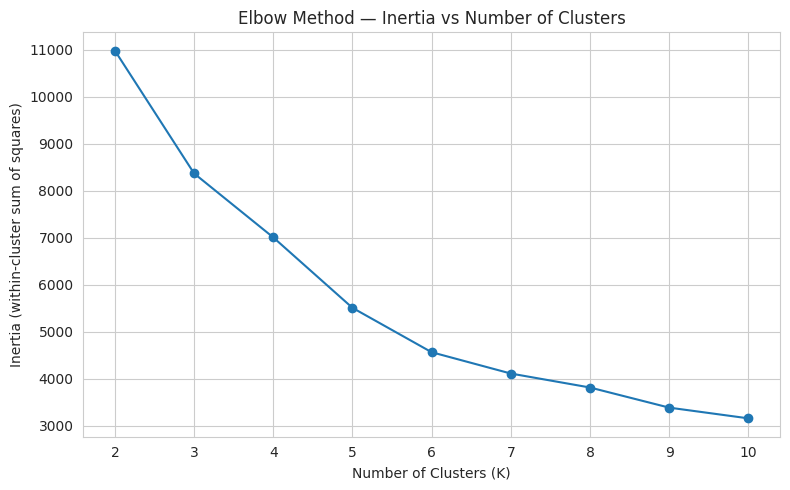

In [6]:
K_range = range(2, 11)
inertia_values = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia_values, marker="o")
plt.title("Elbow Method — Inertia vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.xticks(list(K_range))
plt.grid(True)
plt.tight_layout()
plt.show()

## Section 8 — Silhouette Score Analysis

 K  Silhouette Score  Smallest Cluster Size
 2            0.3532                    739
 3            0.4289                    275
 4            0.4496                    253
 5            0.4569                      2
 6            0.4696                      2
 7            0.4781                      2
 8            0.4492                      1
 9            0.4171                      2
10            0.4137                      1


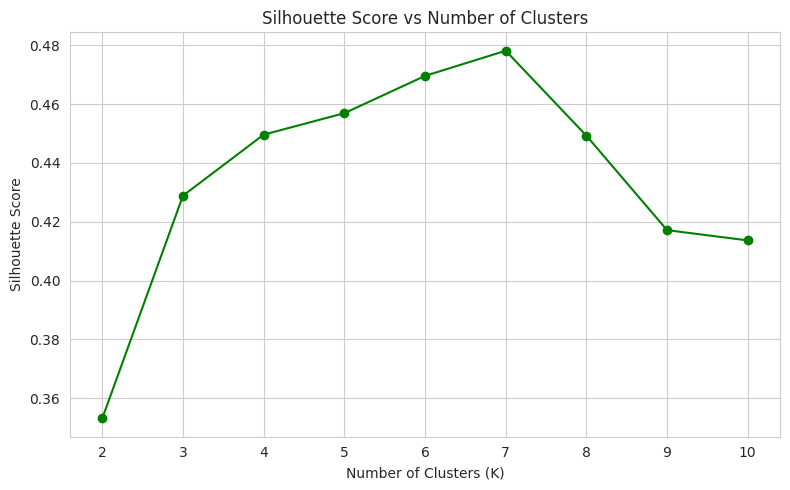

Best K by Silhouette Score : 7
Best Silhouette Score      : 0.4781


In [7]:
sil_scores = []
min_sizes = []                      # smallest cluster size at each K (for Section 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    min_sizes.append(int(pd.Series(labels).value_counts().min()))

sil_table = pd.DataFrame({"K": list(K_range),
                          "Silhouette Score": np.round(sil_scores, 4),
                          "Smallest Cluster Size": min_sizes})
print(sil_table.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), sil_scores, marker="o", color="green")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.grid(True)
plt.tight_layout()
plt.show()

best_k_by_silhouette = int(sil_table.loc[sil_table["Silhouette Score"].idxmax(), "K"])
best_sil = sil_table["Silhouette Score"].max()
print("Best K by Silhouette Score :", best_k_by_silhouette)
print("Best Silhouette Score      :", round(best_sil, 4))

## Section 9 — Select Final Number of Clusters (Final K)



In [8]:
# --- (a) automatic elbow point: the K farthest from the straight line
#         joining the first and last points of the inertia curve ---
xk = np.array(list(K_range)); yk = np.array(inertia_values)
x1, y1 = xk[0], yk[0]; x2, y2 = xk[-1], yk[-1]
line_dist = np.abs((y2 - y1) * xk - (x2 - x1) * yk + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
elbow_k = int(xk[line_dist.argmax()])

# --- (b) reject solutions with a tiny cluster (a simple interpretability guard) ---
min_cluster_needed = max(10, int(0.01 * len(df)))     # at least 1% of the data (or 10)
sil_df = pd.DataFrame({"K": list(K_range), "sil": sil_scores, "min_size": min_sizes})
eligible = sil_df[sil_df["min_size"] >= min_cluster_needed]

# --- (c) final choice: best silhouette among the reasonably-sized solutions ---
if len(eligible) > 0:
    final_k = int(eligible.loc[eligible["sil"].idxmax(), "K"])
else:
    final_k = elbow_k     # fallback if every K produced a tiny cluster

print("Automatic elbow K              :", elbow_k)
print("Best K by silhouette (raw)     :", best_k_by_silhouette)
print("Minimum cluster size required  :", min_cluster_needed)
print("Selected final_k               :", final_k)

# To choose a different value after viewing both graphs, edit the line below:
# final_k = 5

Automatic elbow K              : 5
Best K by silhouette (raw)     : 7
Minimum cluster size required  : 16
Selected final_k               : 4


## Section 10 — Train the Final K-Means Model

In [9]:
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# add cluster labels to the original dataframe (original data is preserved)
df["Cluster"] = kmeans.labels_

df[["Food Name", "Food Category", "Cluster"]].head(10)

,Food Name,Food Category,Cluster
0,A bean with well-balanced flavor and hearty te...,Vegetables Prepared/Processed,2
1,A bean with well-balanced flavor and hearty te...,Vegetables Prepared/Processed,2
2,A bean with well-balanced flavor and hearty te...,Vegetables Prepared/Processed,2
3,A blend of 4 juices by NAKED,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",2
4,A blend of 4 juices with added ingredients & o...,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",2
5,A blend of 4 juices with added ingredients & o...,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",2
6,"A blend of black beans, spinach, kale, kidney ...",Frozen Prepared Sides,2
7,"A blend of black beans, spinach, kale, kidney ...",Frozen Prepared Sides,2
8,"A blend of broccoli florets in a rich, creamy ...",Other Soups,2
9,"A blend of broccoli florets in a rich, creamy ...",Other Soups,2


## Section 11 — Cluster Size Analysis

 Cluster  Number of Foods  Percentage
       0              310       19.27
       1              253       15.72
       2              774       48.10
       3              272       16.90


/tmp/ipykernel_2121/1900899279.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size.index, y=size.values, palette="viridis")


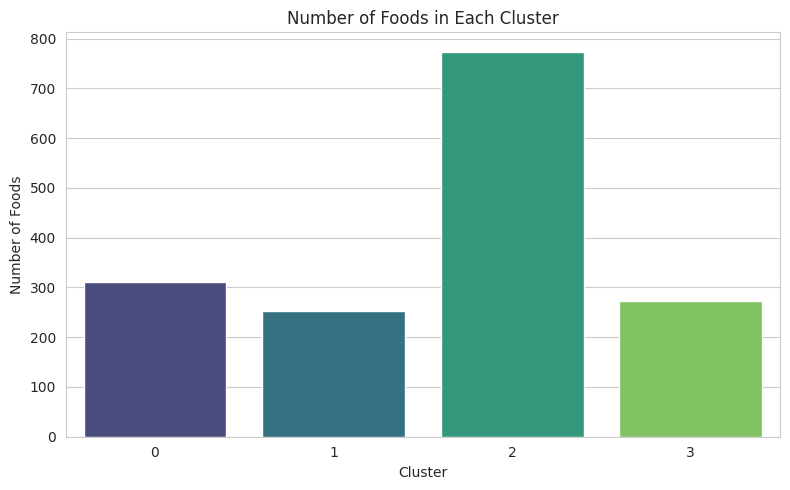

In [10]:
size = df["Cluster"].value_counts().sort_index()
size_table = pd.DataFrame({
    "Cluster": size.index,
    "Number of Foods": size.values,
    "Percentage": np.round(size.values / len(df) * 100, 2)
})
print(size_table.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=size.index, y=size.values, palette="viridis")
plt.title("Number of Foods in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Foods")
plt.tight_layout()
plt.show()

## Section 12 — Cluster Centers in Original Units


In [11]:
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df.index = [f"Cluster {i}" for i in range(final_k)]
centers_df.round(2)

,Calories (kcal),Protein (g),Total Fat (g),Carbohydrates (g),Fiber (g),Sugar (g),Sodium (mg),Cholesterol (mg),Potassium (mg)
Cluster 0,398.99,10.87,12.15,69.55,1.75,46.37,9.40,5.86,5.37
Cluster 1,494.05,24.90,32.59,44.28,9.93,16.26,67.91,0.43,14.58
Cluster 2,81.71,5.92,2.51,12.54,1.65,5.17,28.61,1.44,4.23
Cluster 3,314.81,40.67,23.32,5.97,0.17,2.69,23.66,27.55,3.22


## Section 13 — Average Nutrients by Cluster

In [12]:
avg_nutrients = df.groupby("Cluster")[features].mean().round(2)
avg_nutrients

,Calories (kcal),Protein (g),Total Fat (g),Carbohydrates (g),Fiber (g),Sugar (g),Sodium (mg),Cholesterol (mg),Potassium (mg)
Cluster,,,,,,,,,
0,398.99,10.87,12.15,69.55,1.75,46.37,9.40,5.86,5.37
1,494.05,24.90,32.59,44.28,9.93,16.26,67.91,0.43,14.58
2,81.71,5.92,2.51,12.54,1.65,5.17,28.61,1.44,4.23
3,314.81,40.67,23.32,5.97,0.17,2.69,23.66,27.55,3.22


## Section 14 — Standardized Cluster Profile


In [13]:
X_scaled_df["Cluster"] = kmeans.labels_
std_profile = X_scaled_df.groupby("Cluster")[features].mean().round(2)
std_profile

,Calories (kcal),Protein (g),Total Fat (g),Carbohydrates (g),Fiber (g),Sugar (g),Sodium (mg),Cholesterol (mg),Potassium (mg)
Cluster,,,,,,,,,
0,0.80,-0.29,-0.03,1.54,-0.20,1.58,-0.08,-0.06,-0.06
1,1.31,0.54,1.25,0.62,1.47,0.09,0.14,-0.55,1.02
2,-0.87,-0.58,-0.63,-0.54,-0.22,-0.46,-0.01,-0.46,-0.20
3,0.36,1.47,0.67,-0.78,-0.52,-0.58,-0.02,1.87,-0.32


## Section 15 — Cluster Interpretation


In [14]:
HIGH = 0.5    # a nutrient is "clearly high" if its standardized mean >= 0.5
LOW  = -0.5   # "clearly low" if <= -0.5

def suggest_label(row):
    """Build a neutral label from the ACTUAL standardized cluster means.
    Uses more than one nutrient where appropriate. Makes no food-type or
    biological assumptions (e.g. it never infers 'animal-based')."""
    def high(nut): return row[nut] >= HIGH

    cal, prot, fat = "Calories (kcal)", "Protein (g)", "Total Fat (g)"
    carb, fiber, sugar = "Carbohydrates (g)", "Fiber (g)", "Sugar (g)"
    sod, chol, pot = "Sodium (mg)", "Cholesterol (mg)", "Potassium (mg)"

    # combined profiles (only if BOTH nutrients are actually high)
    if high(carb) and high(sugar):
        return "High-Carbohydrate / High-Sugar Foods"
    if high(fat) and high(cal):
        return "High-Fat / High-Calorie Foods"
    if high(prot) and high(chol):
        return "High-Protein / High-Cholesterol Foods"
    if high(fiber) and high(pot):
        return "High-Fiber / High-Potassium Foods"

    # single dominant nutrient
    if high(prot):  return "High-Protein Foods"
    if high(sod):   return "High-Sodium Foods"
    if high(chol):  return "High-Cholesterol Foods"
    if high(sugar): return "High-Sugar Foods"
    if high(carb):  return "High-Carbohydrate Foods"
    if high(fat):   return "High-Fat Foods"
    if high(fiber): return "High-Fiber Foods"
    if high(cal):   return "High-Calorie Foods"

    # no clearly-high nutrient
    if (row < 0).sum() >= 6 and row[cal] < 0:
        return "Lower-Calorie / Lower-Nutrient Foods"
    return "Mixed Nutrient Profile"

rows = []
for c in range(final_k):
    prof = std_profile.loc[c]
    highs = prof[prof >= HIGH].sort_values(ascending=False).index
    lows = prof[prof <= LOW].sort_values().index
    highs_txt = ", ".join(h.split(" (")[0] for h in highs) or "none clearly high"
    lows_txt = ", ".join(l.split(" (")[0] for l in lows) or "none clearly low"
    rows.append([c, f"High: {highs_txt} | Low: {lows_txt}", suggest_label(prof)])

interpretation = pd.DataFrame(rows,
    columns=["Cluster", "Main Nutritional Characteristics", "Suggested Interpretation"])
interpretation

,Cluster,Main Nutritional Characteristics,Suggested Interpretation
0,0,"High: Sugar, Carbohydrates, Calories | Low: no...",High-Carbohydrate / High-Sugar Foods
1,1,"High: Fiber, Calories, Total Fat, Potassium, C...",High-Fat / High-Calorie Foods
2,2,"High: none clearly high | Low: Calories, Total...",Lower-Calorie / Lower-Nutrient Foods
3,3,"High: Cholesterol, Protein, Total Fat | Low: C...",High-Protein / High-Cholesterol Foods


## Section 16 — Example Foods from Each Cluster


In [15]:
for c in range(final_k):
    print(f"\n================ Cluster {c} ================")
    sample = df[df["Cluster"] == c][["Food Name", "Food Category", "Cluster"]].head(8)
    print(sample.to_string(index=False))


================ Cluster 0 ================
                                                                                                                                                                                                                         Food Name                            Food Category  Cluster
                                                                                  A blend of dates, dried pineapple, banana chips, raisins, dried papaya and dried coconut bite size tropical mix, dried tropical by CHESTNUT HILL                         Wholesome Snacks        0
                                         A blend of dates, dried pineapple, banana chips, raisins, dried papaya and dried coconut bite size tropical mix, dried tropical by family dollar stores inc. by Family Dollar Stores Inc.                         Wholesome Snacks        0
                                         A blend of dates, dried pineapple, banana chips, raisins, dried papaya and dried co

## Section 17 — Food Category Distribution Within Clusters


In [16]:
for c in range(final_k):
    print(f"\nCluster {c} — top 5 food categories:")
    print(df[df["Cluster"] == c]["Food Category"].value_counts().head(5).to_string())


Cluster 0 — top 5 food categories:
Food Category
Cookies & Biscuits                          82
Candy                                       33
Gelatin, Gels, Pectins & Desserts           28
Chocolate                                   25
Popcorn, Peanuts, Seeds & Related Snacks    20

Cluster 1 — top 5 food categories:
Food Category
Chocolate                                   42
Popcorn, Peanuts, Seeds & Related Snacks    35
Chips, Pretzels & Snacks                    31
Snack, Energy & Granola Bars                26
Cereal                                      17

Cluster 2 — top 5 food categories:
Food Category
Pre-Packaged Fruit & Vegetables        115
Pickles, Olives, Peppers & Relishes     90
Other Drinks                            40
Dips & Salsa                            39
Frozen Vegetables                       34

Cluster 3 — top 5 food categories:
Food Category
Cheese                                               153
Cooked & Prepared                                     27
M

## Section 18 — PCA Visualization (2D)


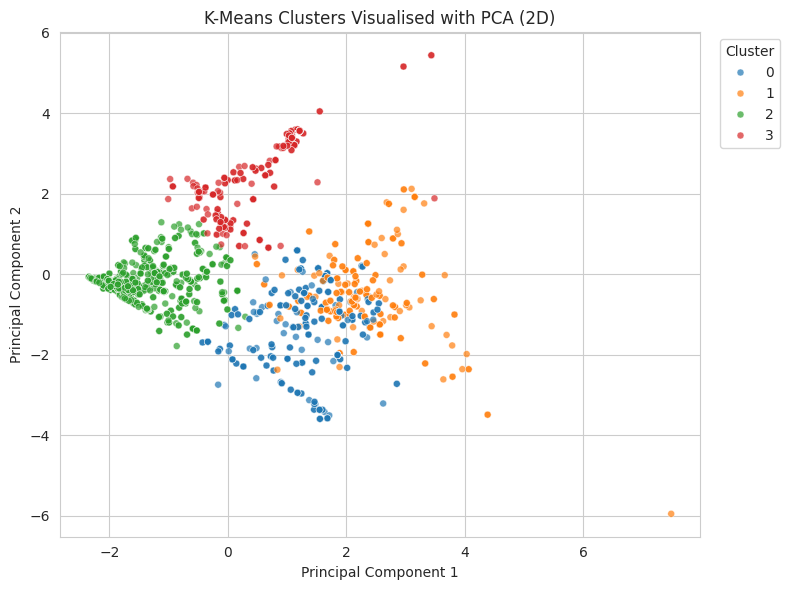

In [17]:
pca = PCA(n_components=2)                  # standard PCA (no random_state needed)
pcs = pca.fit_transform(X_scaled)          # X_scaled = the 9-feature scaled data

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pca_df["Cluster"] = kmeans.labels_

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster",
                palette="tab10", s=25, alpha=0.7)
plt.title("K-Means Clusters Visualised with PCA (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Section 19 — Cluster Heatmap (Standardized Means)


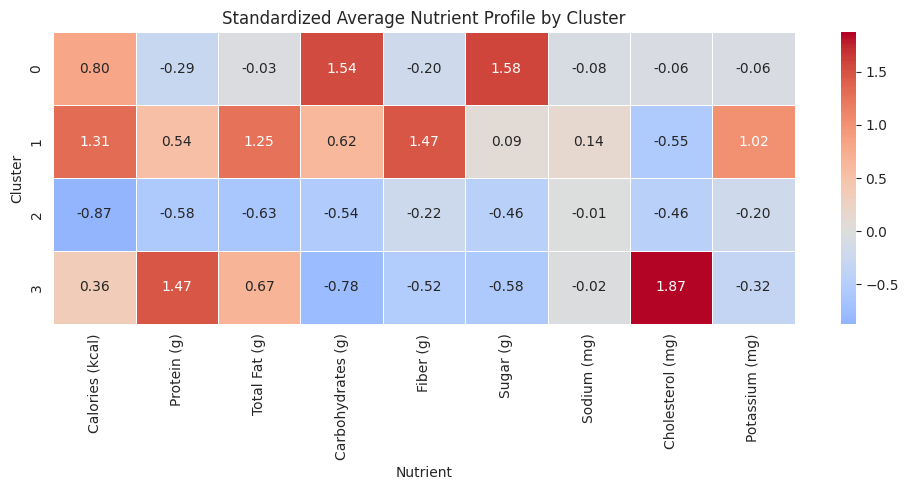

In [18]:
plt.figure(figsize=(10, 5))
sns.heatmap(std_profile, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            linewidths=0.5)
plt.title("Standardized Average Nutrient Profile by Cluster")
plt.xlabel("Nutrient")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## Section 20 — Nutrient Comparison Charts

/tmp/ipykernel_2121/3947593865.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cal_means.index, y=cal_means.values, palette="viridis")


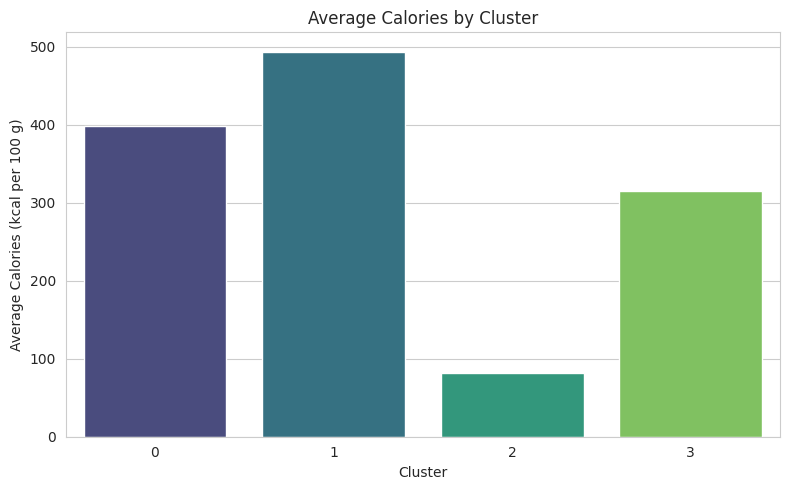

In [19]:
# Four separate charts (one nutrient each) — no subplots.

# 1) Average Calories by Cluster
cal_means = df.groupby("Cluster")["Calories (kcal)"].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=cal_means.index, y=cal_means.values, palette="viridis")
plt.title("Average Calories by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Calories (kcal per 100 g)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2121/3926873165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pro_means.index, y=pro_means.values, palette="viridis")


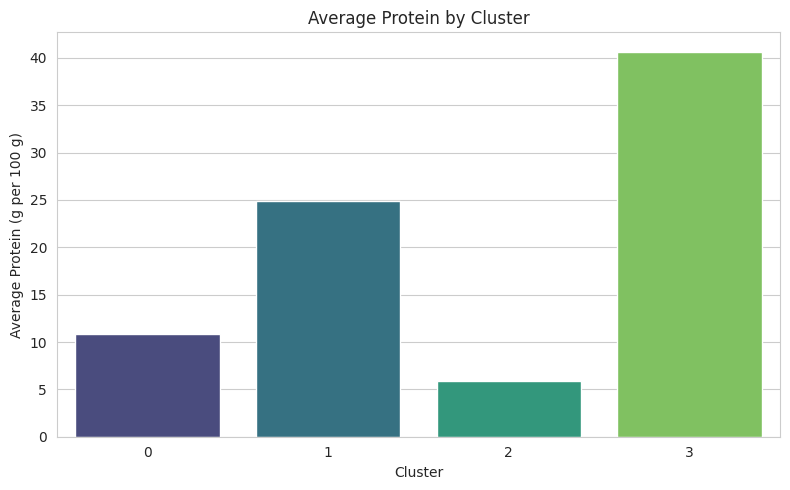

In [20]:
# 2) Average Protein by Cluster
pro_means = df.groupby("Cluster")["Protein (g)"].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=pro_means.index, y=pro_means.values, palette="viridis")
plt.title("Average Protein by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Protein (g per 100 g)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2121/694975116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fat_means.index, y=fat_means.values, palette="viridis")


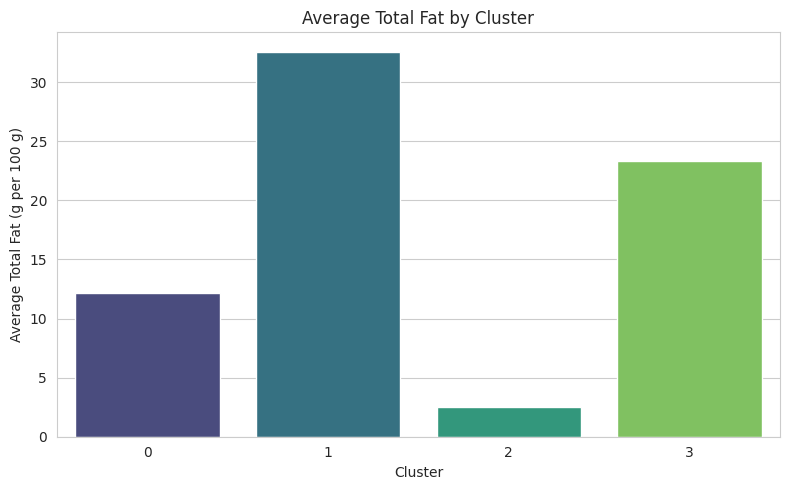

In [21]:
# 3) Average Total Fat by Cluster
fat_means = df.groupby("Cluster")["Total Fat (g)"].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=fat_means.index, y=fat_means.values, palette="viridis")
plt.title("Average Total Fat by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Fat (g per 100 g)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2121/3221821840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carb_means.index, y=carb_means.values, palette="viridis")


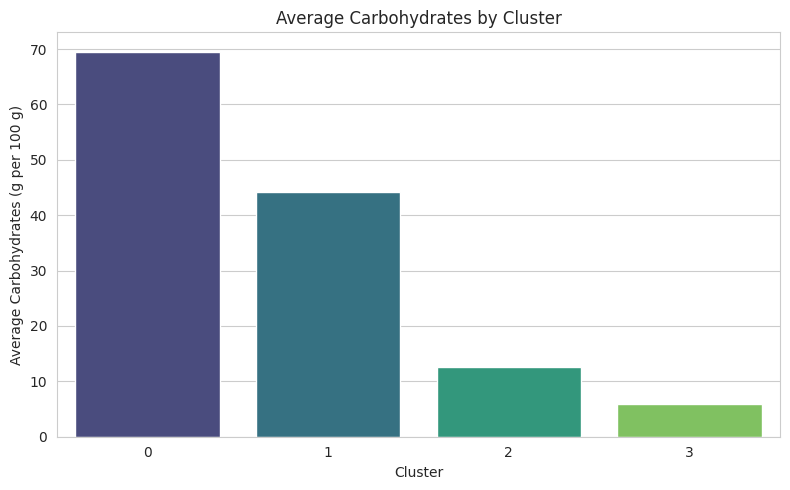

In [22]:
# 4) Average Carbohydrates by Cluster
carb_means = df.groupby("Cluster")["Carbohydrates (g)"].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=carb_means.index, y=carb_means.values, palette="viridis")
plt.title("Average Carbohydrates by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Carbohydrates (g per 100 g)")
plt.tight_layout()
plt.show()

## Section 21 — Model Evaluation


In [23]:
final_inertia = kmeans.inertia_
final_sil = silhouette_score(X_scaled, kmeans.labels_)

# interpret the ACTUAL score (not a fixed assumption)
if final_sil >= 0.70:
    interpretation_text = "strong cluster separation"
elif final_sil >= 0.50:
    interpretation_text = "reasonably good cluster separation"
elif final_sil >= 0.25:
    interpretation_text = "moderate or partly overlapping cluster structure"
else:
    interpretation_text = "weak cluster separation"

print("Final K                :", final_k)
print("Final Inertia          :", round(final_inertia, 2))
print("Final Silhouette Score :", round(final_sil, 4))
print("Interpretation         :", interpretation_text)

Final K                : 4
Final Inertia          : 7006.57
Final Silhouette Score : 0.4496
Interpretation         : moderate or partly overlapping cluster structure


## Section 22 — Key Insights


In [24]:
avg = df.groupby("Cluster")[features].mean()
size = df["Cluster"].value_counts().sort_index()
# nutrient whose cluster-centres vary the most = the most distinguishing nutrient
distinguishing = std_profile.std().idxmax()

print("================ KEY INSIGHTS ================\n")
print(f"1. K-Means produced {final_k} clusters from {len(df)} foods using 9 nutrients.")
print(f"2. Largest cluster : Cluster {size.idxmax()} with {size.max()} foods.")
print(f"3. Smallest cluster: Cluster {size.idxmin()} with {size.min()} foods.")
print(f"4. Highest average calories : Cluster {avg['Calories (kcal)'].idxmax()} "
      f"(~{avg['Calories (kcal)'].max():.0f} kcal/100 g).")
print(f"5. Highest average protein  : Cluster {avg['Protein (g)'].idxmax()} "
      f"(~{avg['Protein (g)'].max():.1f} g).")
print(f"6. Highest average total fat: Cluster {avg['Total Fat (g)'].idxmax()} "
      f"(~{avg['Total Fat (g)'].max():.1f} g).")
print(f"7. Highest average carbs    : Cluster {avg['Carbohydrates (g)'].idxmax()} "
      f"(~{avg['Carbohydrates (g)'].max():.1f} g).")
print(f"8. Highest average sugar    : Cluster {avg['Sugar (g)'].idxmax()} "
      f"(~{avg['Sugar (g)'].max():.1f} g).")
print(f"9. Highest average fiber    : Cluster {avg['Fiber (g)'].idxmax()} "
      f"(~{avg['Fiber (g)'].max():.1f} g).")
print(f"10. Highest average sodium  : Cluster {avg['Sodium (mg)'].idxmax()} "
      f"(~{avg['Sodium (mg)'].max():.0f} mg).")
largest_pct = size.max() / len(df) * 100
smallest_pct = size.min() / len(df) * 100
# simple rule of thumb (not a formal standard): flag if the largest cluster is
# more than 5x the smallest
balance = "imbalanced" if size.max() > 5 * size.min() else "fairly balanced"
print(f"11. Cluster sizes range from {smallest_pct:.1f}% to {largest_pct:.1f}% of all "
      f"foods; by a simple 5x rule-of-thumb they look {balance}.")
print(f"12. The nutrient that most distinguishes the clusters is: {distinguishing}.")

================ KEY INSIGHTS ================

1. K-Means produced 4 clusters from 1609 foods using 9 nutrients.
2. Largest cluster : Cluster 2 with 774 foods.
3. Smallest cluster: Cluster 1 with 253 foods.
4. Highest average calories : Cluster 1 (~494 kcal/100 g).
5. Highest average protein  : Cluster 3 (~40.7 g).
6. Highest average total fat: Cluster 1 (~32.6 g).
7. Highest average carbs    : Cluster 0 (~69.5 g).
8. Highest average sugar    : Cluster 0 (~46.4 g).
9. Highest average fiber    : Cluster 1 (~9.9 g).
10. Highest average sodium  : Cluster 1 (~68 mg).
11. Cluster sizes range from 15.7% to 48.1% of all foods; by a simple 5x rule-of-thumb they look fairly balanced.
12. The nutrient that most distinguishes the clusters is: Cholesterol (mg).


## Section 23 — Final Result Summary

In [25]:
avg = df.groupby("Cluster")[features].mean()
size = df["Cluster"].value_counts()

summary = pd.DataFrame({
    "Item": [
        "Total records", "Numerical features used", "Final K",
        "Final Inertia", "Final Silhouette Score",
        "Largest cluster", "Smallest cluster",
        "Highest-calorie cluster", "Highest-protein cluster",
        "Highest-fat cluster", "Highest-carbohydrate cluster",
    ],
    "Result": [
        len(df), len(features), final_k,
        round(final_inertia, 2), round(final_sil, 4),
        f"Cluster {size.idxmax()} ({size.max()} foods)",
        f"Cluster {size.idxmin()} ({size.min()} foods)",
        f"Cluster {avg['Calories (kcal)'].idxmax()}",
        f"Cluster {avg['Protein (g)'].idxmax()}",
        f"Cluster {avg['Total Fat (g)'].idxmax()}",
        f"Cluster {avg['Carbohydrates (g)'].idxmax()}",
    ],
})
summary

,Item,Result
0,Total records,1609
1,Numerical features used,9
2,Final K,4
3,Final Inertia,7006.57
4,Final Silhouette Score,0.4496
5,Largest cluster,Cluster 2 (774 foods)
6,Smallest cluster,Cluster 1 (253 foods)
7,Highest-calorie cluster,Cluster 1
8,Highest-protein cluster,Cluster 3
9,Highest-fat cluster,Cluster 1


## Section 24 — Conclusion


In [26]:
print("================ CONCLUSION (from actual results) ================\n")
print(f"- K-Means grouped {len(df)} foods into {final_k} clusters using 9 "
      f"standardized nutrient features.")
print(f"- Final Silhouette Score = {round(final_sil, 4)} "
      f"({interpretation_text}).")
print(f"- Final Inertia = {round(final_inertia, 2)}.")
print("- Cluster characteristics found in this run (data-driven labels):")
for _, r in interpretation.iterrows():
    print(f"    Cluster {r['Cluster']}: {r['Suggested Interpretation']}")
print("\n- PCA was used only for visualisation; K-Means used all 9 features.")
print("- These results are reported as-is, without exaggerating cluster quality.")

================ CONCLUSION (from actual results) ================

- K-Means grouped 1609 foods into 4 clusters using 9 standardized nutrient features.
- Final Silhouette Score = 0.4496 (moderate or partly overlapping cluster structure).
- Final Inertia = 7006.57.
- Cluster characteristics found in this run (data-driven labels):
    Cluster 0: High-Carbohydrate / High-Sugar Foods
    Cluster 1: High-Fat / High-Calorie Foods
    Cluster 2: Lower-Calorie / Lower-Nutrient Foods
    Cluster 3: High-Protein / High-Cholesterol Foods

- PCA was used only for visualisation; K-Means used all 9 features.
- These results are reported as-is, without exaggerating cluster quality.


## Section 25 — Save the Final Clustered Dataset

In [27]:
# attach the suggested interpretation label to each row (optional, for reference)
label_map = dict(zip(interpretation["Cluster"],
                     interpretation["Suggested Interpretation"]))
df["Cluster Interpretation"] = df["Cluster"].map(label_map)

df.to_csv("nutrition_kmeans_clustered.csv", index=False)
print("Saved: nutrition_kmeans_clustered.csv", df.shape)

# also save the supporting result tables
size_table.to_csv("cluster_summary.csv", index=False)
centers_df.round(2).to_csv("cluster_centers.csv")
print("Saved: cluster_summary.csv, cluster_centers.csv")

from google.colab import files
files.download("nutrition_kmeans_clustered.csv")

Saved: nutrition_kmeans_clustered.csv (1609, 13)
Saved: cluster_summary.csv, cluster_centers.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>